## SBI Interactive Tutorial
---

In this interactive tutorial we demonstrate the usage of simulation based inference




In [1]:
import numpy as np
from getdist import plots, MCSamples
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from scipy.linalg import eigh
from nautilus import Prior, Sampler
from sbi.inference import NLE
from sbi.utils import BoxUniform
from sbi.inference.posteriors.posterior_parameters import VIPosteriorParameters
import torch
from tqdm import tqdm

import jax
import jax_cosmo as jc
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

## Notebook outline

We're going to calculate a SDDR with a simple Gaussian model

First, let's define some helper functions


## Plotting function

In [2]:
def triangle_plot(
    mc_samples,
    truth=None,
    params_to_plot=None,
    savefig=False,
    filename=None,
):
    # Triangle plot
    plt.close()
    with mpl.rc_context():
        # g = plots.getSubplotPlotter(width_inch=12)
        g = plots.getSubplotPlotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.6
        g.settings.axes_fontsize = 18
        g.settings.legend_fontsize = 18
        g.settings.lab_fontsize = 18
        if params_to_plot:
            g.triangle_plot(
                mc_samples, params=params_to_plot, filled_compare=True, normalized=True
            )
        else:
            g.triangle_plot(mc_samples, filled_compare=True, normalized=True)

        if truth is not None:
            g.add_param_markers(truth, color="black", ls="--")

        plt.subplots_adjust(hspace=0, wspace=0)

        if savefig:
            plt.savefig(filename, bbox_inches="tight")
        plt.show()
        
def plot_spectra(spectra):
    pass
    

## For a cosmic shear simulator, we need to first define some redshift bins

In [3]:
nz1 = jc.redshift.smail_nz(1., 2.,  0.5)
nz2 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.6), 0.5)
nz3 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.8), 1.2)
nz4 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.0), 1.8)
nz5 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.2), 2.4)

nzs = [nz1, nz2, nz3, nz4, nz5]

## Let's also plot it to convince ourselves things are looking right

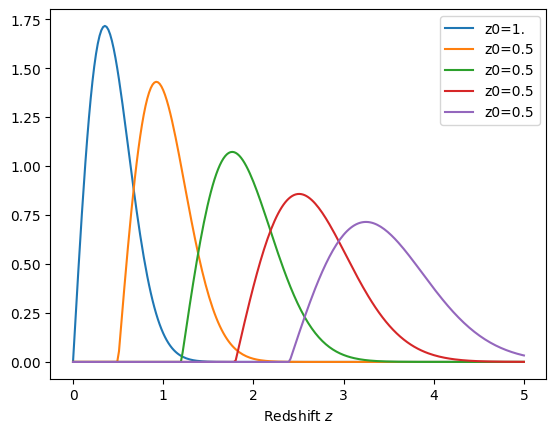

In [4]:
# And let's plot it
z = np.linspace(0,5,256)

# Redshift distributions are callable, and they return the normalized distribution
plt.plot(z, nz1(z), label='z0=1.')
plt.plot(z, nz2(z), label='z0=0.5')
plt.plot(z, nz3(z), label='z0=0.5')
plt.plot(z, nz4(z), label='z0=0.5')
plt.plot(z, nz5(z), label='z0=0.5')
plt.legend()
plt.xlabel('Redshift $z$');

## We also need to define some probes to describe what exactly we are observing

In [5]:
probes = [ jc.probes.WeakLensing(nzs, sigma_e=0.26),]
        #    jc.probes.NumberCounts(nzs, jc.bias.constant_linear_bias(1.)) ]

## Lastly we also need to define the ell range that we want our power spectrum to go up to

In [6]:
ell = np.logspace(np.log10(2), np.log10(1000), 100)

In [7]:
cosmo_data = jc.Planck15()

In [8]:
cls = jc.angular_cl.angular_cl(cosmo_data, ell, probes)
noise_cls = jc.angular_cl.noise_cl(ell, probes)
cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
cls_noise = jax.random.multivariate_normal(mean=jnp.concatenate(cls), cov=cov, key=jax.random.PRNGKey(42))

## Let's plot this all to see what our data vector looks like

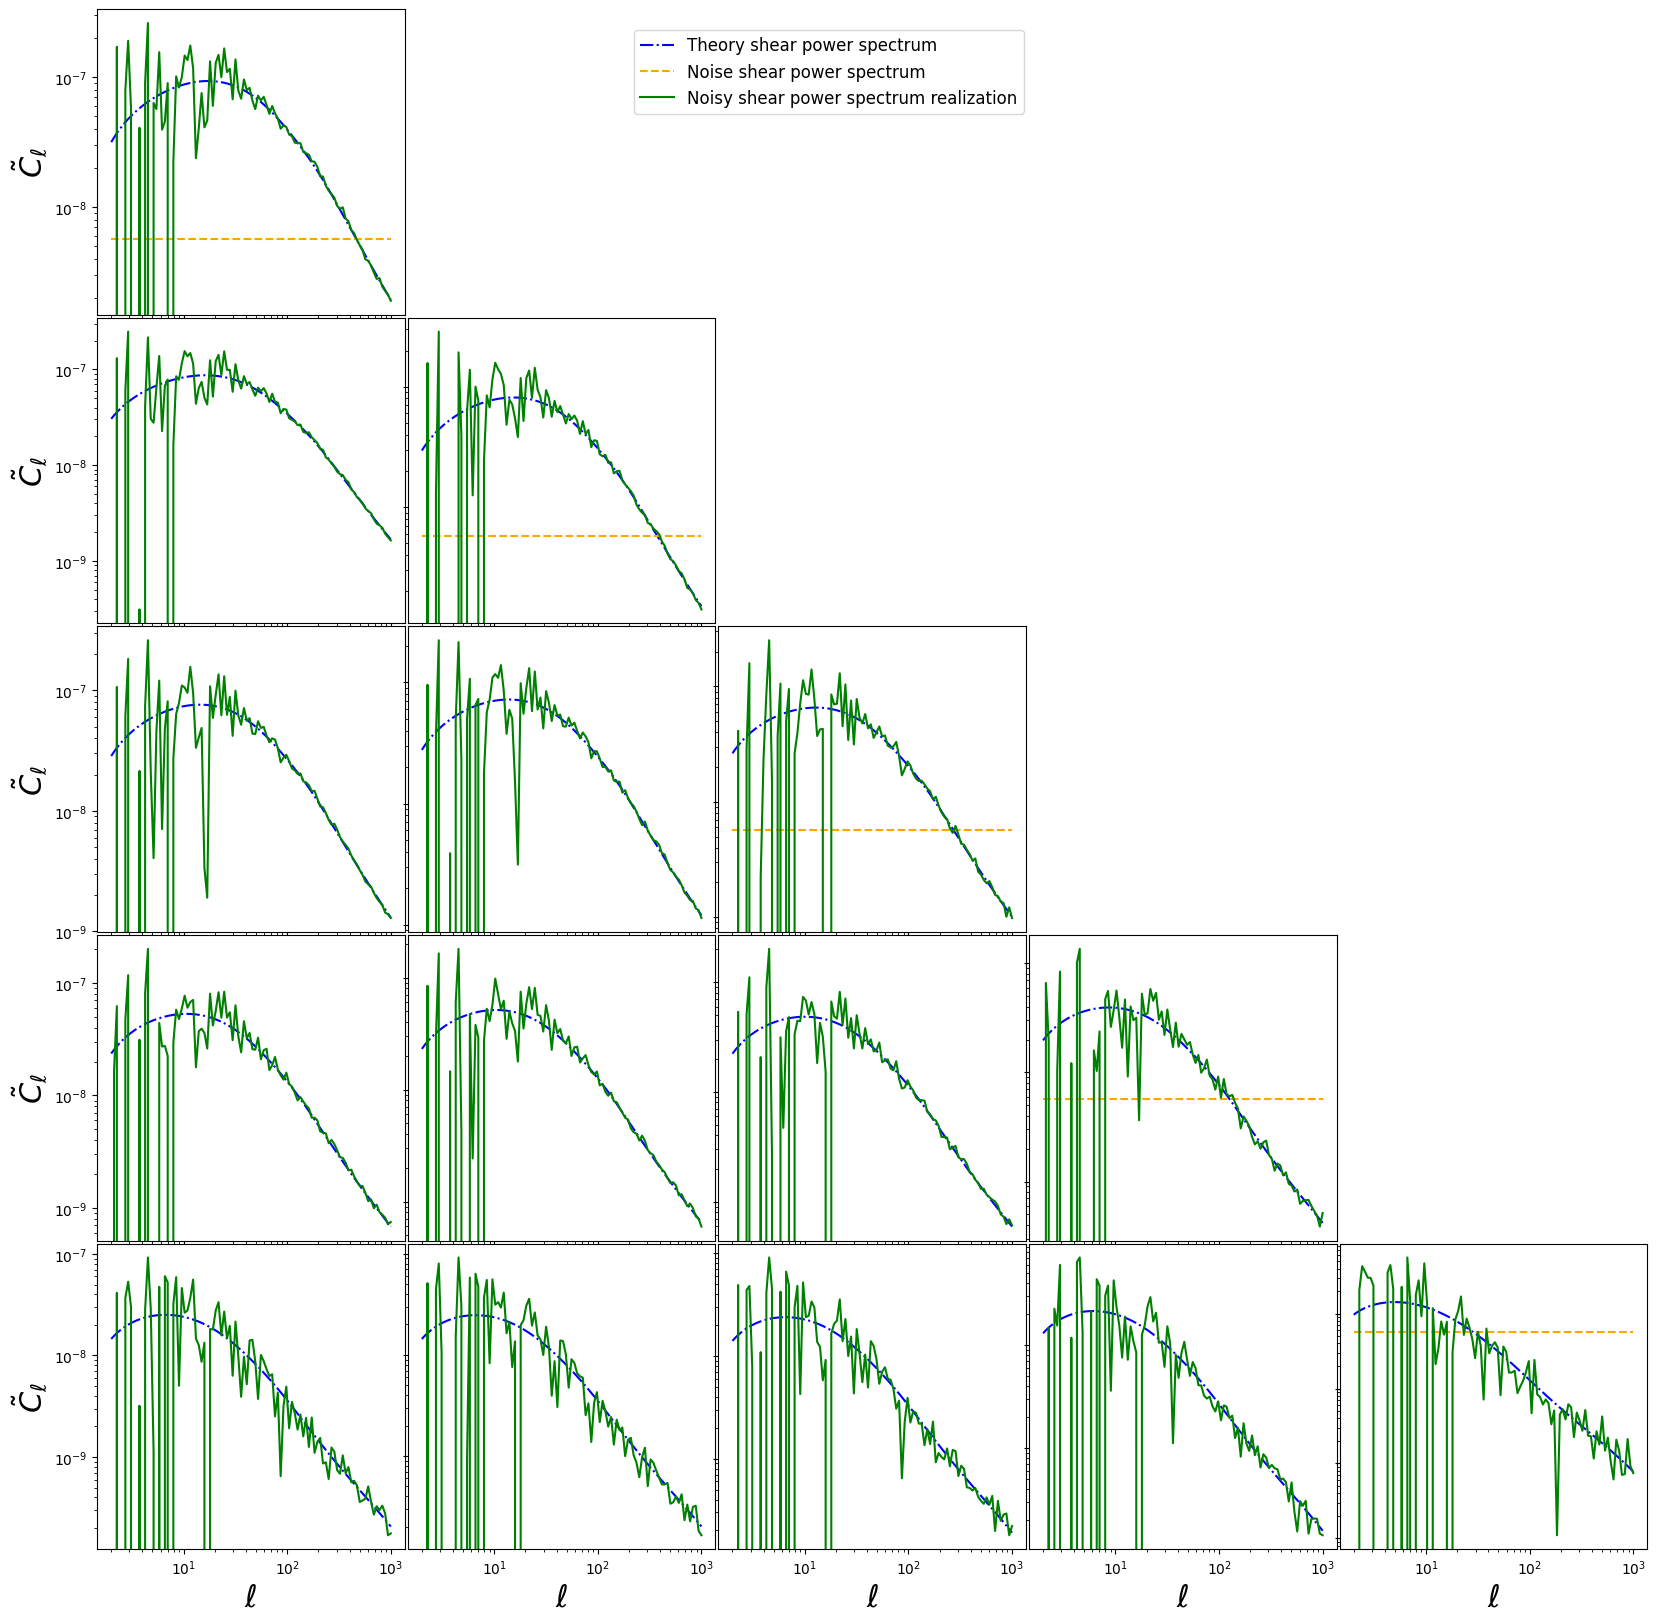

In [9]:
counter=0
fig, axs = plt.subplots(len(nzs), len(nzs), figsize=(20, 20))

cls_plot = cls[::-1]
noise_cls_plot = noise_cls[::-1]
cls_noise_plot = cls_noise.reshape(cls.shape)[::-1]

for i in range(0, len(nzs)):
    for j in range(0, len(nzs)):
        if i<j:
            axs[i, j].axis('off')
        else:
            axs[i, j].plot(ell, cls_plot[counter], c='blue', ls = '-.', label='Theory shear power spectrum')
            axs[i, j].plot(ell, noise_cls_plot[counter], c='orange', ls = '--', label='Noise shear power spectrum')
            axs[i, j].plot(ell, cls_noise_plot[counter], c='green', ls = '-', label='Noisy shear power spectrum realization')
            axs[i, j].set_xscale('log')
            axs[i, j].set_yscale('log')

            if i == len(nzs) - 1:
                axs[i, j].set_xlabel(r'$\ell$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_xticklabels(), visible=False)
            
            if j == 0:
                axs[i, j].set_ylabel(r'$\tilde{C}_{\ell}$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_yticklabels(), visible=False)

            counter += 1

plt.legend(bbox_to_anchor=(-1, 5), loc='upper right', fontsize=12)
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.show()

## Let's also make a basic simulator

In [10]:
@jax.jit
def simulator(theta, key=jax.random.PRNGKey(42)):
    def single_sim(params, rng_key):
        cosmo = jc.Cosmology(
            sigma8=params[0],
            Omega_c=params[1],
            Omega_b=params[2],
            h=params[3],
            n_s=params[4],
            Omega_k=0.0,
            w0=-1.0,
            wa=0.0,
        )
        
        cls = jc.angular_cl.angular_cl(cosmo, ell, probes)
        cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
        
        # Use JAX random generation instead of numpy
        return jax.random.multivariate_normal(rng_key, mean=jnp.concatenate(cls), cov=cov)

    # Split keys so each simulation gets a unique random seed
    keys = jax.random.split(key, theta.shape[0])
    
    # vmap the single simulation function over parameters and keys
    return jax.vmap(single_sim)(theta, keys)

In [11]:
def chunked_simulator(theta, chunk_size=100, key=jax.random.PRNGKey(42)):
    n_samples = theta.shape[0]
    n_chunks = int(np.ceil(n_samples / chunk_size))
    
    # Split the main key so each chunk gets a unique random state
    chunk_keys = jax.random.split(key, n_chunks)
    
    results = []
    for i in tqdm(range(n_chunks)):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_samples)
        
        # Run the JIT-compiled simulator on the current batch
        batch_res = simulator(theta[start:end], key=chunk_keys[i])
        results.append(batch_res)
        
    return jnp.vstack(results)

## Fix the seed


In [12]:
np.random.seed(42)

## Set priors

Can be uniform or gaussian, here we use an uncorrelated Gaussian prior


In [13]:
params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']

lower = torch.tensor([0.5, 0.1, 0.04, 0.64, 0.84])
upper = torch.tensor([1.2, 0.5, 0.06, 0.82, 1.10])

prior = BoxUniform(low=lower, high=upper)

## Let's use the same simulator to generate some simulated data with Gaussian nose

In [14]:
# sim_samples_compression = prior.sample((2000,)).numpy()
# simulated_data_compression = chunked_simulator(sim_samples_compression, chunk_size=10)

In [15]:
# np.save('data/sim_samples_compression.npy', sim_samples_compression)
# np.save('data/simulated_data_compression.npy', simulated_data_compression)

In [16]:
sim_samples_compression = np.load('data/sim_samples_compression.npy')
simulated_data_compression = np.load('data/simulated_data_compression.npy')

## Let's setup a compression method with CCA

In [17]:
n_params = sim_samples_compression.shape[1]

cca_cov = np.cov(sim_samples_compression.T, simulated_data_compression.T)
cp = cca_cov[:n_params,:n_params]
cd = cca_cov[n_params:,n_params:]
cpd = cca_cov[:n_params,n_params:]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T@np.linalg.inv(cp)@cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerical stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector) ) components are real and the rest are noise. 
evals = evals[::-1][:n_params]
evecs = evecs[:,::-1][:,:n_params]

## Now let's also get some data to run the compression on

In [18]:
# sim_samples_sbi = prior.sample((2000,)).numpy()
# simulated_data_sbi = chunked_simulator(sim_samples_sbi, chunk_size=10)

In [19]:
# np.save('data/sim_samples_sbi.npy', sim_samples_sbi)
# np.save('data/simulated_data_sbi.npy', simulated_data_sbi)

In [20]:
# compressed_data = simulated_data_sbi@evecs

## Now let's do some SBI with NLE

In [21]:
num_sims = 1000
num_rounds = 2
inference = NLE(prior)
proposal = prior
compressed_obs = torch.tensor(np.asarray(cls_noise)@evecs, dtype=torch.float32)


In [22]:
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = chunked_simulator(theta.detach().numpy(), chunk_size=10)
    compressed_x = np.asarray(x)@evecs
    compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
    _ = inference.append_simulations(theta, compressed_x).train()
    posterior = inference.build_posterior().set_default_x(compressed_obs)
    proposal = posterior

100%|██████████| 100/100 [00:31<00:00,  3.22it/s]


 Neural network successfully converged after 179 epochs.

/Users/kiyam/Code/academia/sbi_tutorial/.venv/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:26<00:00,  3.74it/s]


 Neural network successfully converged after 22 epochs.

In [23]:
nle_posterior_theta = posterior.sample((20000,), x=compressed_obs, num_chains=100)

Generating 100 MCMC inits via resample strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Running vectorized MCMC with 100 chains:   0%|          | 0/45000 [00:00<?, ?it/s]

In [24]:
nle_posterior_samples = nle_posterior_theta.detach().numpy()
nle_posterior_log_probs = posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

/var/folders/6n/hfj2qpk95wl0p60xd9fg40y00000gn/T/ipykernel_55619/1028913090.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nle_posterior_log_probs = posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


## Get some posterior samples with emcee


## Plot!


In [28]:
param_labels = [r'\sigma_8', r'\Omega_c', r'\Omega_b', r'h', r'n_s']
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]
truth_marker = dict(zip(params, truth))

### Make the getdist MC objects

In [29]:
nle_samples = MCSamples(
    samples=nle_posterior_samples,
    names=params,
    labels=param_labels,
    label="Super SBI model",
    sampler="mcmc",
)

Removed no burn in


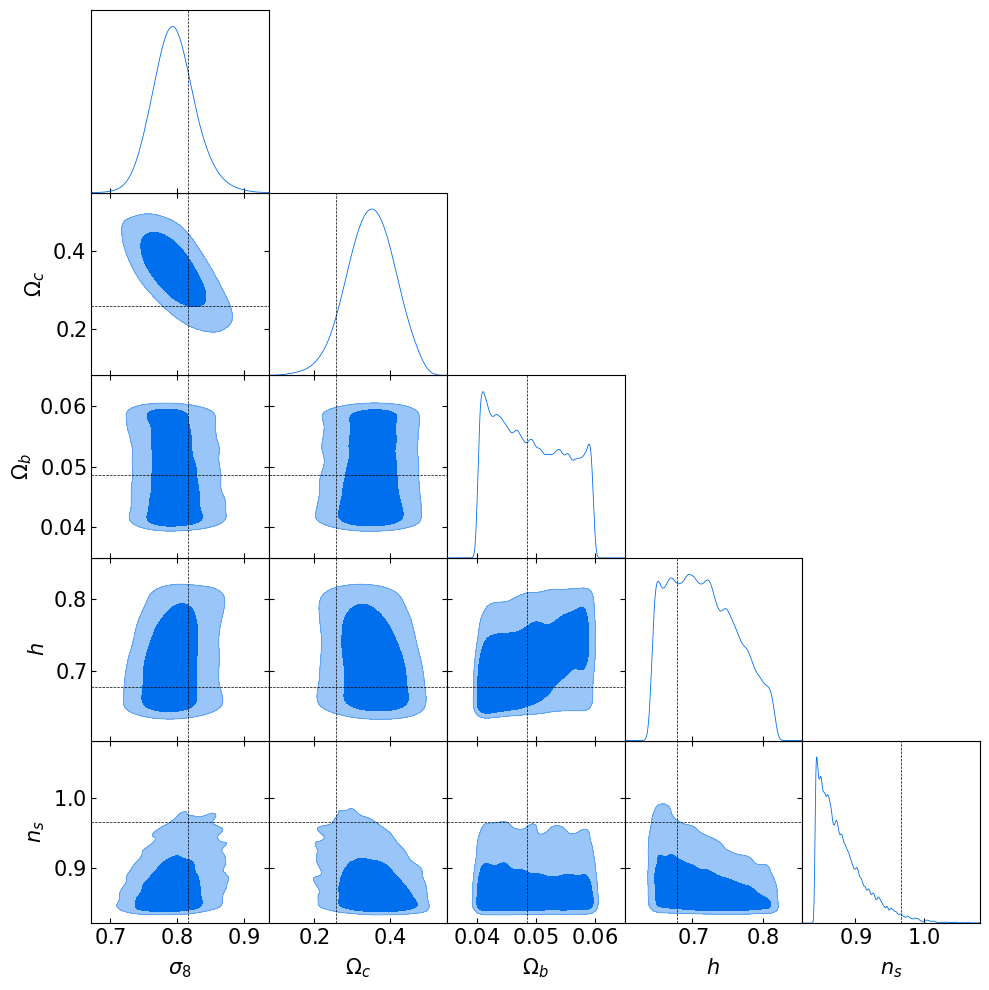

In [30]:
triangle_plot(
    [nle_samples],
    truth=truth_marker)